## <center>CITS5508 Lab sheet 5: Decision tree</center>


In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### 1. Loading the data & Inspecting the data

In [90]:
df = pd.read_csv(
    'abalone.data', 
    header=None, 
    names=[
        'sex', 
        'length', 
        'diameter', 
        'height', 
        'whole_weight', 
        'shucked_weight', 
        'viscera_weight', 
        'shell_weight', 
        'rings'
    ]
)

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             4177 non-null   object 
 1   length          4177 non-null   float64
 2   diameter        4177 non-null   float64
 3   height          4177 non-null   float64
 4   whole_weight    4177 non-null   float64
 5   shucked_weight  4177 non-null   float64
 6   viscera_weight  4177 non-null   float64
 7   shell_weight    4177 non-null   float64
 8   rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [92]:
df.describe()

,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


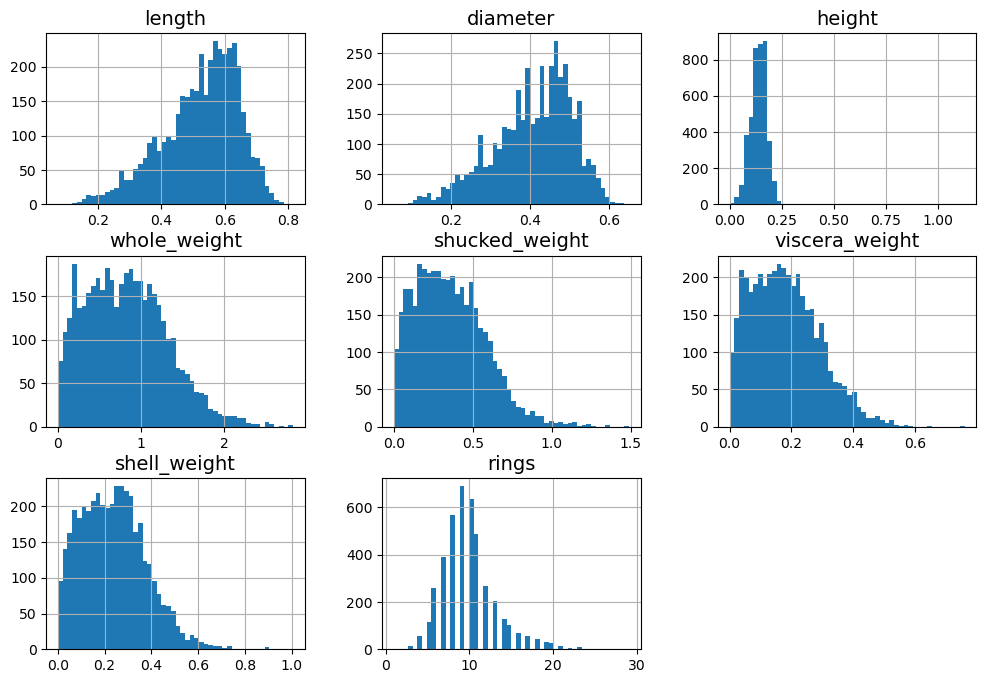

In [93]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

df.hist(bins=50, figsize=(12, 8))
plt.show()

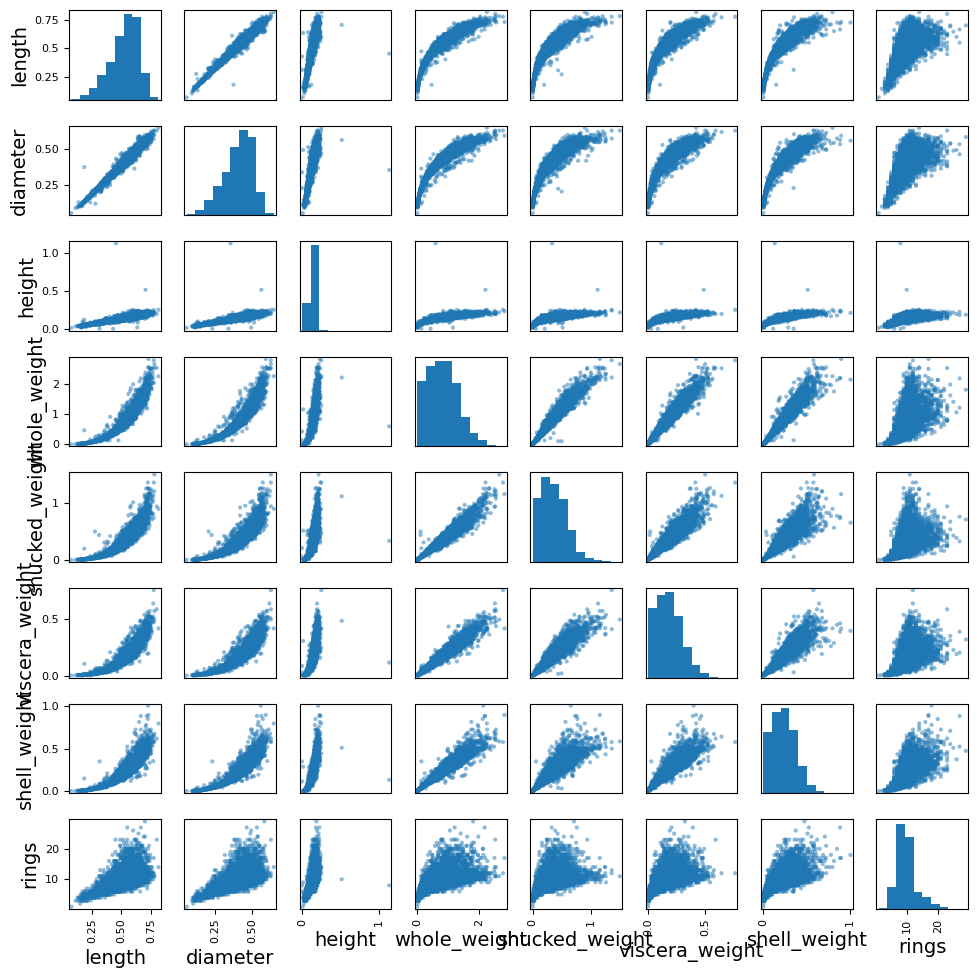

In [94]:
from pandas.plotting import scatter_matrix

scatter_matrix(df, figsize=(10, 10))

plt.tight_layout()
plt.show()

In [95]:
df.corr(numeric_only=True).style.background_gradient().format('{:.2f}')

,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
length,1.00,0.99,0.83,0.93,0.90,0.90,0.90,0.56
diameter,0.99,1.00,0.83,0.93,0.89,0.90,0.91,0.57
height,0.83,0.83,1.00,0.82,0.77,0.80,0.82,0.56
whole_weight,0.93,0.93,0.82,1.00,0.97,0.97,0.96,0.54
shucked_weight,0.90,0.89,0.77,0.97,1.00,0.93,0.88,0.42
viscera_weight,0.90,0.90,0.80,0.97,0.93,1.00,0.91,0.50
shell_weight,0.90,0.91,0.82,0.96,0.88,0.91,1.00,0.63
rings,0.56,0.57,0.56,0.54,0.42,0.50,0.63,1.00


#### 2. Data preprocessing

- sex: need to be changed to numeric values(can use one-hot encoder)

In [96]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
sex_encoded = encoder.fit_transform(df[['sex']])

sex_encoded_df = pd.DataFrame(
    sex_encoded,
    columns=encoder.get_feature_names_out(['sex']),
)

df_encoded = pd.concat([df, sex_encoded_df], axis=1)
df_encoded = df_encoded.drop(columns='sex')
print(df_encoded.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   length          4177 non-null   float64
 1   diameter        4177 non-null   float64
 2   height          4177 non-null   float64
 3   whole_weight    4177 non-null   float64
 4   shucked_weight  4177 non-null   float64
 5   viscera_weight  4177 non-null   float64
 6   shell_weight    4177 non-null   float64
 7   rings           4177 non-null   int64  
 8   sex_F           4177 non-null   float64
 9   sex_I           4177 non-null   float64
 10  sex_M           4177 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 359.1 KB
None


#### 3. Splitting of data

In [97]:
from sklearn.model_selection import train_test_split

x = df_encoded.drop(columns='rings')
y = df_encoded['rings']

x_train, x_test , y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

#### 4. Training a Decision Tree Regressor using default hyperparameters.

In [98]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

dec_tree_reg = DecisionTreeRegressor(random_state=42)
dec_tree_reg.fit(x_train, y_train)


DecisionTreeRegressor(random_state=42)

In [99]:
print(f'depth={dec_tree_reg.get_depth()}')
print(f'n_leaves={dec_tree_reg.get_n_leaves()}')

depth=25
n_leaves=2089


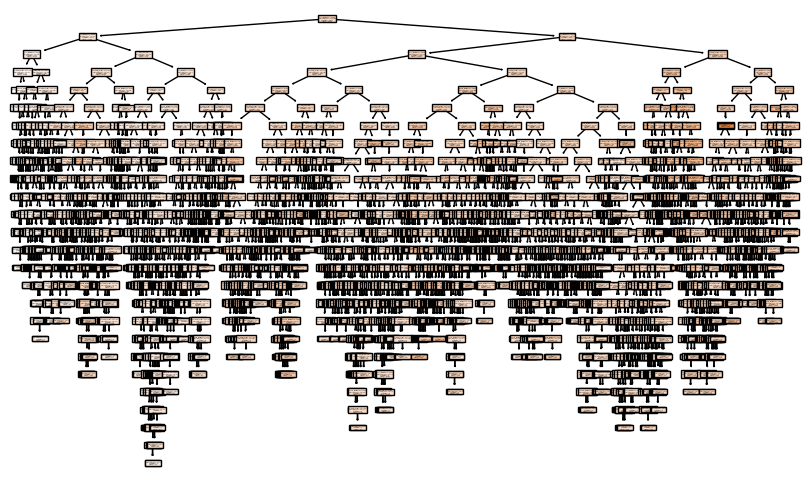

In [100]:
plt.figure(figsize=(10,6))
plot_tree(dec_tree_reg, filled=True, feature_names=x_train.columns)
plt.show()

##### Observation

No, this totally doesnt make sense, theres too much nodes in the tree

#### 5. Select a performance measure and inspect the model performance on the training and test data.

In [101]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = dec_tree_reg.predict(x_test)
mae = mean_absolute_error(y_true=y_test, y_pred=y_pred)
mse = mean_squared_error(y_true=y_test, y_pred=y_pred)
rmse = np.sqrt(mse)
print(f'mae: {mae:.5f}')
print(f'mse: {mse:.5f}')
print(f'rmse: {rmse:.5f}')
# R^2
print(f'train R^2={dec_tree_reg.score(x_train, y_train):.3f}')
print(f'test R^2={dec_tree_reg.score(x_test, y_test):3f}')

mae: 2.07656
mse: 9.67464
rmse: 3.11041
train R^2=1.000
test R^2=0.118890


#### 6. Provide a plot with the model predictions and the “true” values for the test set.

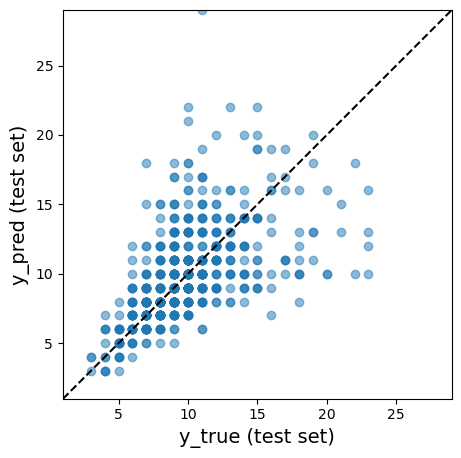

In [102]:
fig, ax = plt.subplots()

ax.scatter(y_test, dec_tree_reg.predict(x_test), alpha=0.5)
ax.plot([df['rings'].min(), df['rings'].max()], [df['rings'].min(), df['rings'].max()], 'k--')
ax.set_xlim(df['rings'].min(), df['rings'].max())
ax.set_ylim(df['rings'].min(), df['rings'].max())
ax.set_aspect('equal')
ax.set_xlabel('y_true (test set)')
ax.set_ylabel('y_pred (test set)')


plt.tight_layout()
plt.show()


Residuals are not randomly spread around 0.

At higher predicted rings, residuals are mostly negative, which means overprediction in that region.

There are some large outliers (very negative residuals), meaning big errors for some samples.

#### 7. Using 5-CV to experiment different hyperparameters
Using 5-fold cross-validation, experiment with different hyperparameters (e.g., max depth, min samples split) and observe their impact on model performance. With the optimal obtained hyperparameters, retrain the model and compare the model’s performance on the training and test setswith the one using the default hyperparameters. 

In [103]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid={
        'max_depth': [3, 5, 7, 9, 11],
        'min_samples_split': [2, 50, 100, 200],
        'max_leaf_nodes': [10, 15, 20, 25, 30, 50],
    },
    cv=5,
    refit=True,
    n_jobs=1
)

grid_search.fit(x_train, y_train)
print(f'best_params: {grid_search.best_params_}')
y_pred = grid_search.predict(x_test)
mae = mean_absolute_error(y_true=y_test, y_pred=y_pred)
mse = mean_squared_error(y_true=y_test, y_pred=y_pred)
rmse = np.sqrt(mse)
print(f'mae: {mae:.5f}')
print(f'mse: {mse:.5f}')
print(f'rmse: {rmse:.5f}')

print(f'train R^2={grid_search.score(x_train, y_train):.3f}')
print(f'test R^2={grid_search.score(x_test, y_test):3f}')

best_params: {'max_depth': 9, 'max_leaf_nodes': 30, 'min_samples_split': 100}
mae: 1.59387
mse: 5.34544
rmse: 2.31202
train R^2=0.566
test R^2=0.513168


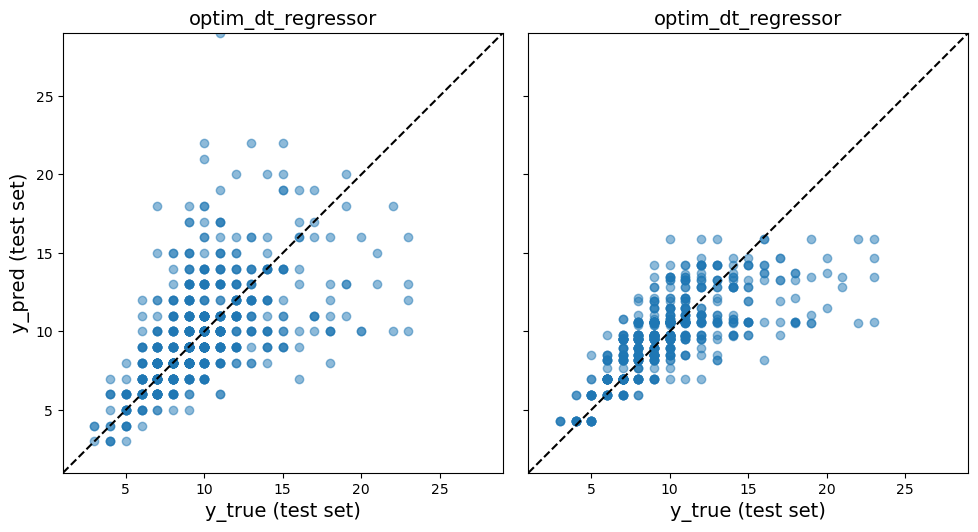

In [104]:
fig, axis = plt.subplots(1,2, figsize=(10,6), sharex=True, sharey=True)
axis[0].scatter(y_test, dec_tree_reg.predict(x_test), alpha=0.5)
axis[1].scatter(y_test, grid_search.predict(x_test), alpha=0.5)

for ax in axis:
    ax.plot([df['rings'].min(), df['rings'].max()], [df['rings'].min(), df['rings'].max()], 'k--')
    ax.set_xlim(df['rings'].min(), df['rings'].max())
    ax.set_ylim(df['rings'].min(), df['rings'].max())
    ax.set_aspect('equal')
    ax.set_xlabel('y_true (test set)')
    ax.set_title('optim_dt_regressor')

axis[0].set_ylabel('y_pred (test set)')

plt.tight_layout()
plt.show()

#### 9. Visualize the fine-tuned decision tree model to understand how it makes predictions. Interpret the tree structure and identify important features.

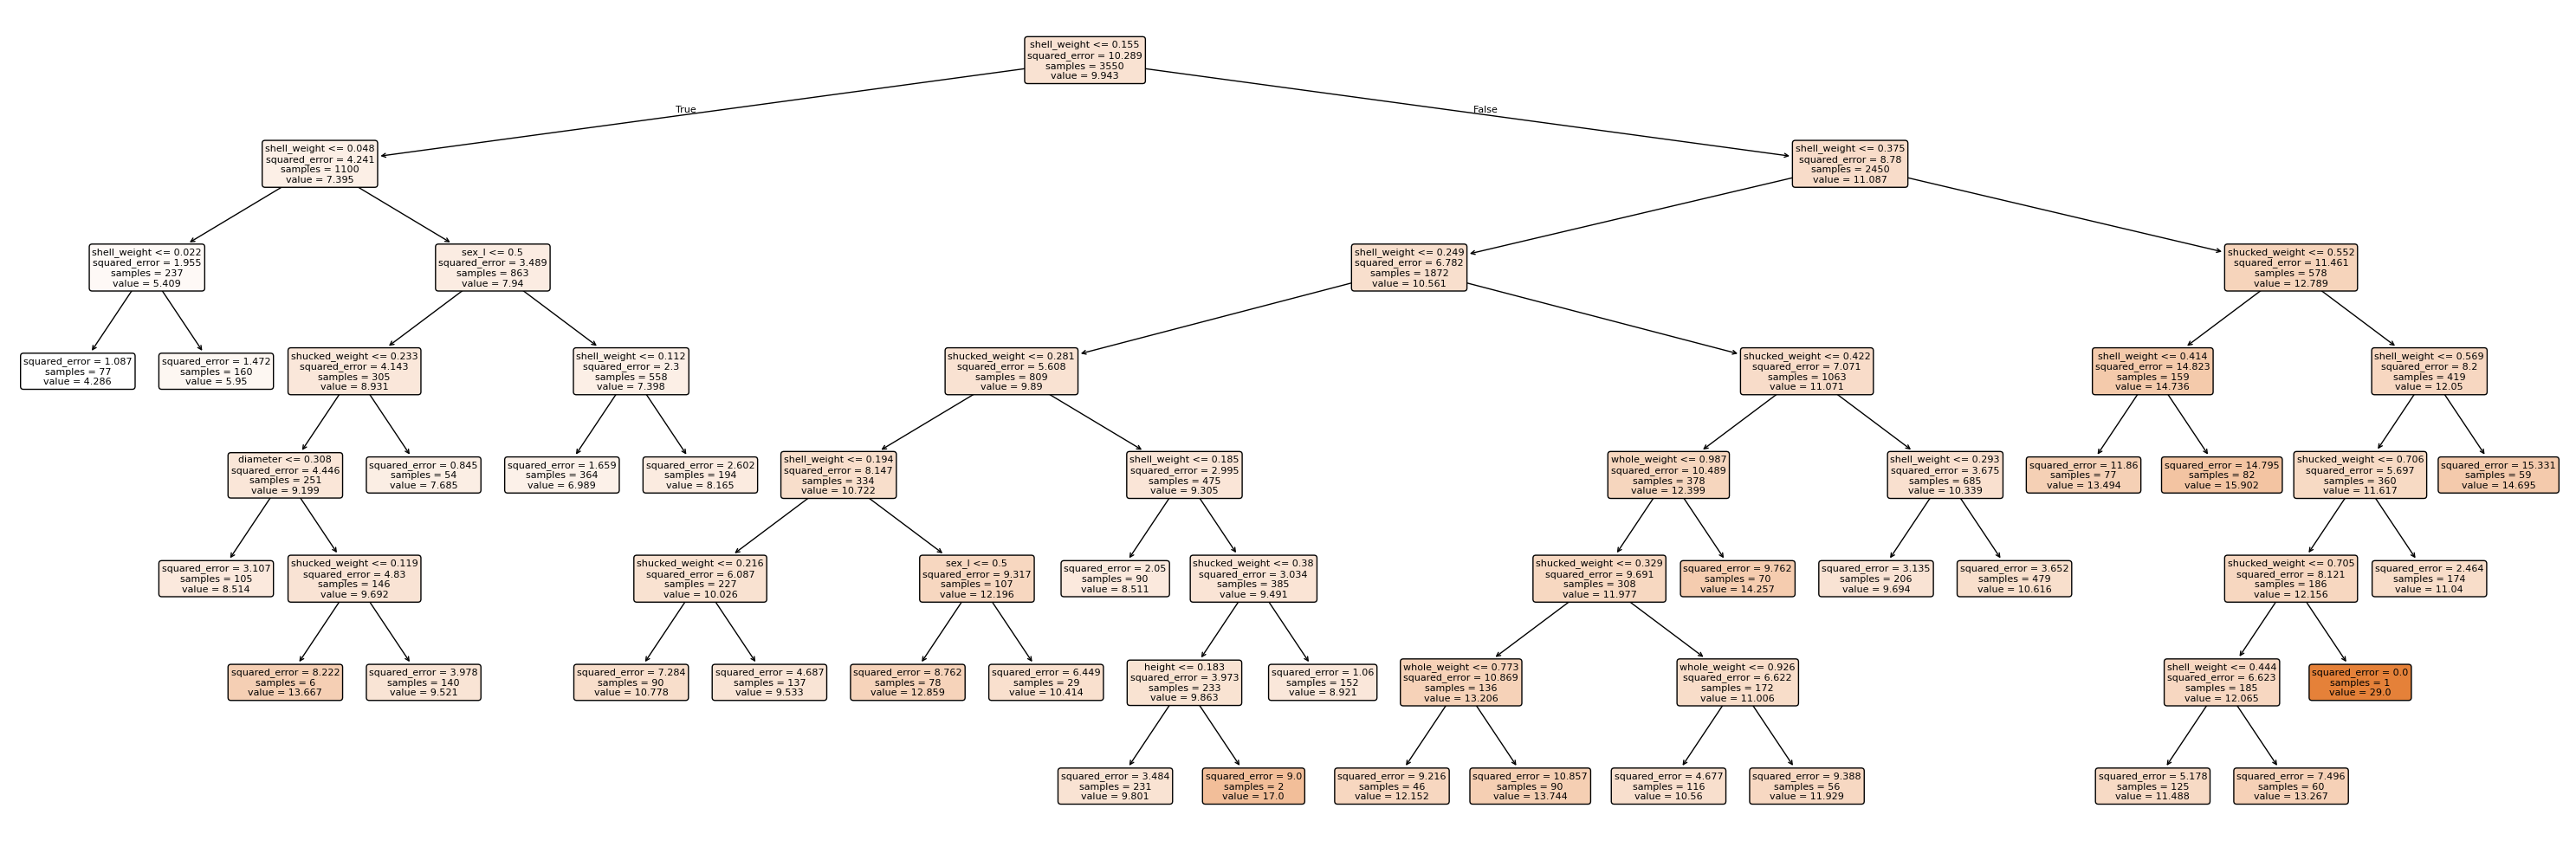

In [105]:
from sklearn.tree import plot_tree

plt.figure(figsize=(30, 10))
plot_tree(
    grid_search.best_estimator_,
    feature_names=x.columns,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.tight_layout()
plt.show()

#### 10. Comparing to SVM Regressor

In [106]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR

svr = GridSearchCV(
    make_pipeline(
        StandardScaler(),
        SVR()
    ),
    param_grid={
        'svr__C': [0.1, 1, 10, 100],
        'svr__gamma': ['scale', 'auto'],
        'svr__epsilon': [0.01, 0.1, 1],
        'svr__kernel': ['poly', 'rbf', 'sigmoid'],
    },
    cv=5,
    refit=True,
    n_jobs=-1
)

svr.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('svr', SVR())]),
             n_jobs=-1,
             param_grid={'svr__C': [0.1, 1, 10, 100],
                         'svr__epsilon': [0.01, 0.1, 1],
                         'svr__gamma': ['scale', 'auto'],
                         'svr__kernel': ['poly', 'rbf', 'sigmoid']})

In [107]:
print(f'train R^2={svr.score(x_train, y_train):.3f}')
print(f'test R^2={svr.score(x_test, y_test):3f}')

train R^2=0.589
test R^2=0.578072
